In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings("ignore")

In [31]:
df = pd.read_csv("customer_churn_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   customer_id  tenure  monthly_charges  total_charges        contract  \
0            1      52            54.20        2818.40  Month-to-month   
1            2      15            35.28         529.20  Month-to-month   
2            3      72            78.24        5633.28  Month-to-month   
3            4      61            80.24        4894.64        One year   
4            5      21            39.38         826.98  Month-to-month   

  payment_method internet_service tech_support online_security  support_calls  \
0         Credit              DSL           No             Yes              1   
1          Debit              DSL           No              No              2   
2          Debit              DSL           No              No              0   
3           Cash            Fiber          Yes             Yes              0   
4            UPI            Fiber           No              No              4   

  churn  
0    No  
1    No  
2    No  
3    No  
4   Yes  
<class '

In [32]:
df.drop("customer_id", axis=1, inplace=True)

In [33]:
print(df.isnull().sum())

tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64


In [34]:
df['internet_service'] = df['internet_service'].bfill()
df.isnull().sum()

tenure              0
monthly_charges     0
total_charges       0
contract            0
payment_method      0
internet_service    0
tech_support        0
online_security     0
support_calls       0
churn               0
dtype: int64

In [35]:
df.drop_duplicates(inplace=True)

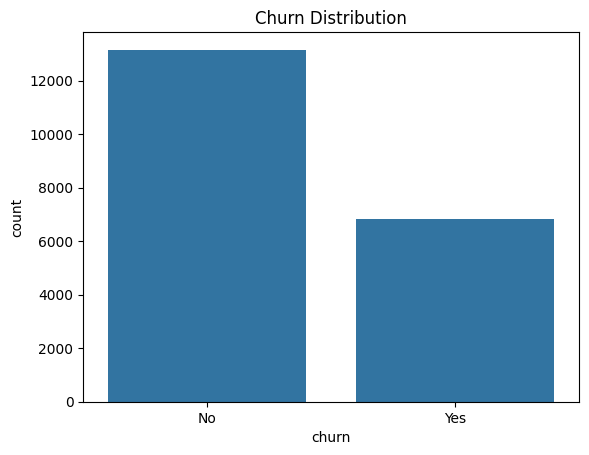

In [36]:
plt.figure()
sns.countplot(x=df["churn"])
plt.title("Churn Distribution")
plt.show()

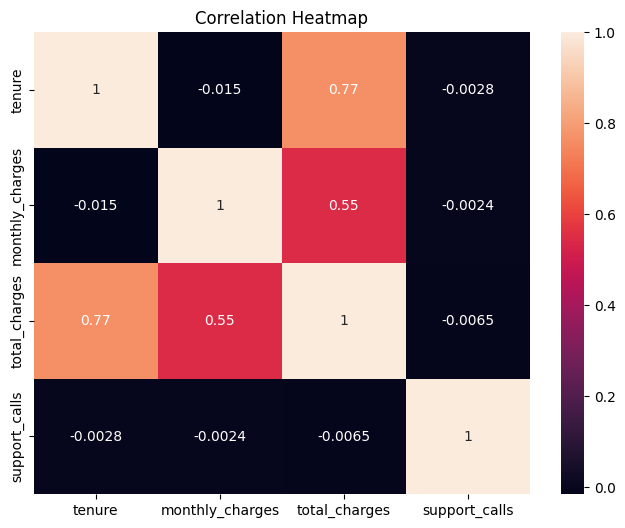

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

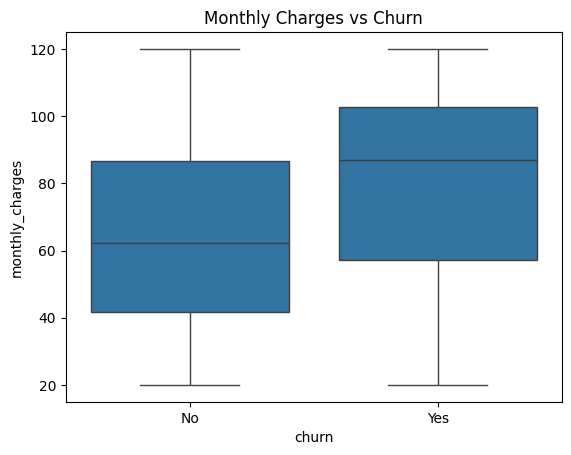

In [38]:
plt.figure()
sns.boxplot(x="churn", y="monthly_charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [39]:
df["avg_charge_per_month"] = df["total_charges"] / (df["tenure"] + 1)

In [40]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [41]:
y = y.map({"No": 0, "Yes": 1})

In [42]:
numeric_features = ["tenure", "monthly_charges", "total_charges", "support_calls", "avg_charge_per_month"]

categorical_features = ["contract", "payment_method", "internet_service", "tech_support", "online_security"]

In [43]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),  # SMOTE AFTER encoding
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {"accuracy": acc, "roc_auc": roc}
    
    print("\n", name)
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.6825
ROC-AUC: 0.6683919461775005
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      2632
           1       0.53      0.61      0.57      1368

    accuracy                           0.68      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.69      0.68      0.69      4000


 Decision Tree
Accuracy: 0.6825
ROC-AUC: 0.661629139337706
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      2632
           1       0.53      0.61      0.57      1368

    accuracy                           0.68      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.69      0.68      0.69      4000


 Random Forest
Accuracy: 0.6825
ROC-AUC: 0.6611500493254412
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      2632
           1       0.53      0.61      0.57      

In [46]:
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [47]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

final_pipeline = grid_search.best_estimator_

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 200}
Best Score: 0.6896056384807753


In [48]:
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:,1]

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Final Accuracy: 0.67475
Final ROC-AUC: 0.6639612661974084
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      2632
           1       0.52      0.56      0.54      1368

    accuracy                           0.67      4000
   macro avg       0.64      0.65      0.64      4000
weighted avg       0.68      0.67      0.68      4000



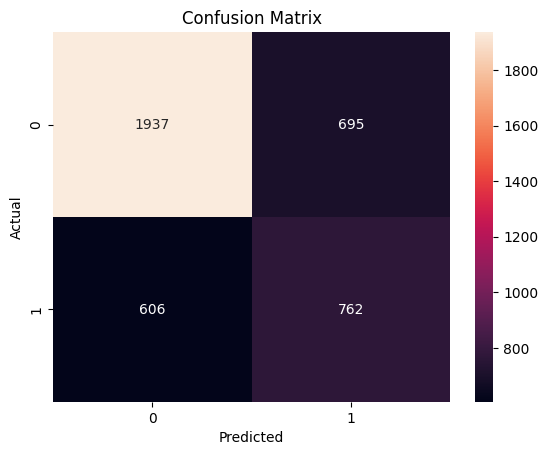

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

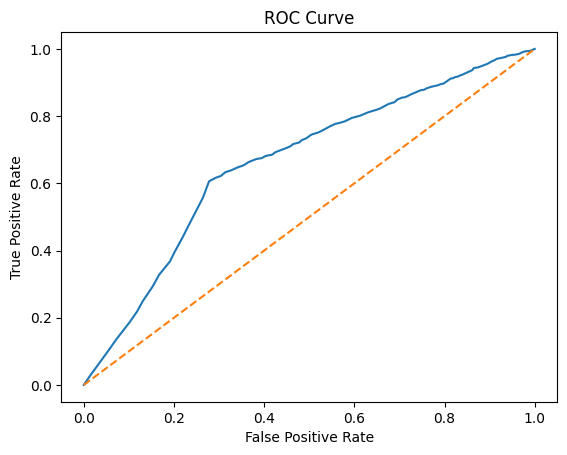

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [51]:
cv_score = cross_val_score(final_pipeline, X, y, cv=5, scoring="accuracy")
print("Cross Validation Accuracy:", cv_score.mean())

Cross Validation Accuracy: 0.6880343335833958


In [52]:
joblib.dump(final_pipeline, "customer_churn_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
